# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Quek Yong Hao



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [19]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly

# 1. Business Understanding
Goal: estimate appliances energy use in a low energy building

# 2. Data Understanding

## 2.1 Load dataset

In [20]:
## Read *.csv file into pandas DataFrame
FILE_PATH = "energydata_complete.csv"

df = pd.read_csv(FILE_PATH)

## Rename columns to be more understandable
df = df.rename(columns={
    'date': 'DateTime',
    'Appliances': 'EnergyUse(Wh)',
    'lights': 'LightsEnergyUse(Wh)',
    'T1': 'KitchenTemperature(C)',
    'RH_1': 'KitchenHumidity(%)',
    'T2': 'LivingRoomTemperature(C)',
    'RH_2': 'LivingRoomHumidity(%)',
    'T3': 'LaundryRoomTemperature(C)',
    'RH_3': 'LaundryRoomHumidity(%)',
    'T4': 'OfficeTemperature(C)',
    'RH_4': 'OfficeHumidity(%)',
    'T5': 'BathroomTemperature(C)',
    'RH_5': 'BathroomHumidity(%)',
    'T6': 'OutsideNorthTemperature(C)',
    'RH_6': 'OutsideNorthHumidity(%)',
    'T7': 'IroningRoomTemperature(C)',
    'RH_7': 'IroningRoomHumidity(%)',
    'T8': 'Teenager2RoomTemperature(C)',
    'RH_8': 'Teenager2RoomHumidity(%)',
    'T9': 'ParentsRoomTemperature(C)',
    'RH_9': 'ParentsRoomHumidity(%)',
    'T_out': 'OutsideTemperature_Station(C)',
    'Press_mm_hg': 'Pressure(mmHg)',
    'RH_out': 'OutsideHumidity_Station(%)',
    'Windspeed': 'WindSpeed(m/s)',
    'Visibility': 'Visibility(km)',
    'Tdewpoint': 'DewPointTemperature(C)',
    'rv1': 'RandomVariable1',
    'rv2': 'RandomVariable2'
})

df = df.drop(['ParentsRoomHumidity(%)','Teenager2RoomHumidity(%)','IroningRoomHumidity(%)','OutsideNorthHumidity(%)','BathroomHumidity(%)','OfficeHumidity(%)','LaundryRoomHumidity(%)','LivingRoomHumidity(%)','KitchenHumidity(%)','RandomVariable1','RandomVariable2','OutsideHumidity_Station(%)','OutsideTemperature_Station(C)','DewPointTemperature(C)','Pressure(mmHg)','WindSpeed(m/s)','Visibility(km)','LightsEnergyUse(Wh)','DateTime'], axis=1)

df ## Display dataframe

,EnergyUse(Wh),KitchenTemperature(C),LivingRoomTemperature(C),LaundryRoomTemperature(C),OfficeTemperature(C),BathroomTemperature(C),OutsideNorthTemperature(C),IroningRoomTemperature(C),Teenager2RoomTemperature(C),ParentsRoomTemperature(C)
0,60,19.890000,19.200000,19.790000,19.000000,17.166667,7.026667,17.200000,18.2000,17.033333
1,60,19.890000,19.200000,19.790000,19.000000,17.166667,6.833333,17.200000,18.2000,17.066667
2,50,19.890000,19.200000,19.790000,18.926667,17.166667,6.560000,17.200000,18.2000,17.000000
3,50,19.890000,19.200000,19.790000,18.890000,17.166667,6.433333,17.133333,18.1000,17.000000
4,60,19.890000,19.200000,19.790000,18.890000,17.200000,6.366667,17.200000,18.1000,17.000000
...,...,...,...,...,...,...,...,...,...,...
19730,100,25.566667,25.890000,27.200000,24.700000,23.200000,24.796667,24.500000,24.7000,23.200000
19731,90,25.500000,25.754000,27.133333,24.700000,23.230000,24.196667,24.557143,24.7000,23.200000
19732,270,25.500000,25.628571,27.050000,24.700000,23.230000,23.626667,24.540000,24.7000,23.200000
19733,420,25.500000,25.414000,26.890000,24.700000,23.200000,22.433333,24.500000,24.6625,23.200000


## 2.2 Summary Statistics

In [21]:
## Understand the type of variable for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   EnergyUse(Wh)                19735 non-null  int64  
 1   KitchenTemperature(C)        19735 non-null  float64
 2   LivingRoomTemperature(C)     19735 non-null  float64
 3   LaundryRoomTemperature(C)    19735 non-null  float64
 4   OfficeTemperature(C)         19735 non-null  float64
 5   BathroomTemperature(C)       19735 non-null  float64
 6   OutsideNorthTemperature(C)   19735 non-null  float64
 7   IroningRoomTemperature(C)    19735 non-null  float64
 8   Teenager2RoomTemperature(C)  19735 non-null  float64
 9   ParentsRoomTemperature(C)    19735 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 1.5 MB


In [22]:
## Check for missing data
df.isna().sum()

EnergyUse(Wh)                  0
KitchenTemperature(C)          0
LivingRoomTemperature(C)       0
LaundryRoomTemperature(C)      0
OfficeTemperature(C)           0
BathroomTemperature(C)         0
OutsideNorthTemperature(C)     0
IroningRoomTemperature(C)      0
Teenager2RoomTemperature(C)    0
ParentsRoomTemperature(C)      0
dtype: int64

In [23]:
## Describe data distribution
df.describe(include="all")

,EnergyUse(Wh),KitchenTemperature(C),LivingRoomTemperature(C),LaundryRoomTemperature(C),OfficeTemperature(C),BathroomTemperature(C),OutsideNorthTemperature(C),IroningRoomTemperature(C),Teenager2RoomTemperature(C),ParentsRoomTemperature(C)
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,21.686571,20.341219,22.267611,20.855335,19.592106,7.910939,20.267106,22.029107,19.485828
std,102.524891,1.606066,2.192974,2.006111,2.042884,1.844623,6.090347,2.109993,1.956162,2.014712
min,10.000000,16.790000,16.100000,17.200000,15.100000,15.330000,-6.065000,15.390000,16.306667,14.890000
25%,50.000000,20.760000,18.790000,20.790000,19.530000,18.277500,3.626667,18.700000,20.790000,18.000000
50%,60.000000,21.600000,20.000000,22.100000,20.666667,19.390000,7.300000,20.033333,22.100000,19.390000
75%,100.000000,22.600000,21.500000,23.290000,22.100000,20.619643,11.256000,21.600000,23.390000,20.600000
max,1080.000000,26.260000,29.856667,29.236000,26.200000,25.795000,28.290000,26.000000,27.230000,24.500000


## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

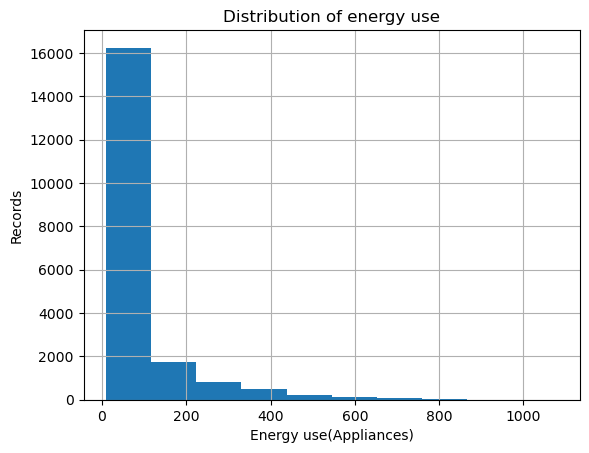

In [24]:
## Understanding distribution of target
col_y = "EnergyUse(Wh)"

##plot histogram
df[col_y].hist()
plt.title(f"Distribution of energy use")
plt.suptitle('')  # Remove default title by Pandas
plt.xlabel("Energy use(Appliances)")
plt.ylabel("Records")
plt.show()

### 2.3.1.2 Understanding distribution of features

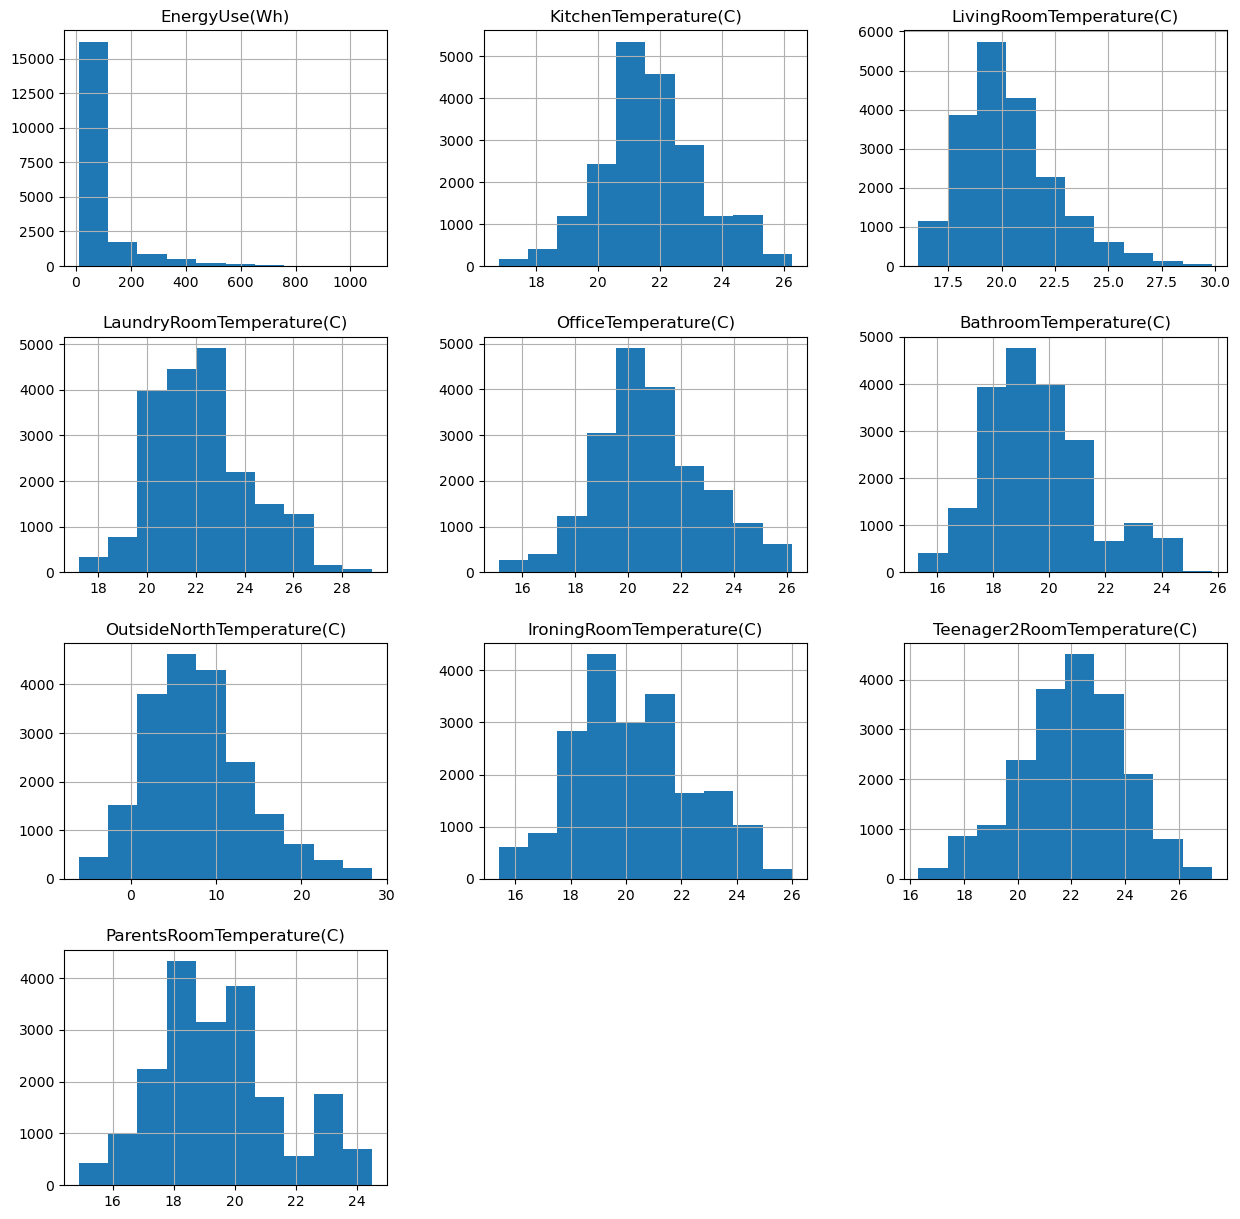

In [25]:
## Understanding distribution of features
## Plot histogram
df.hist(figsize=(15,15))
plt.show()

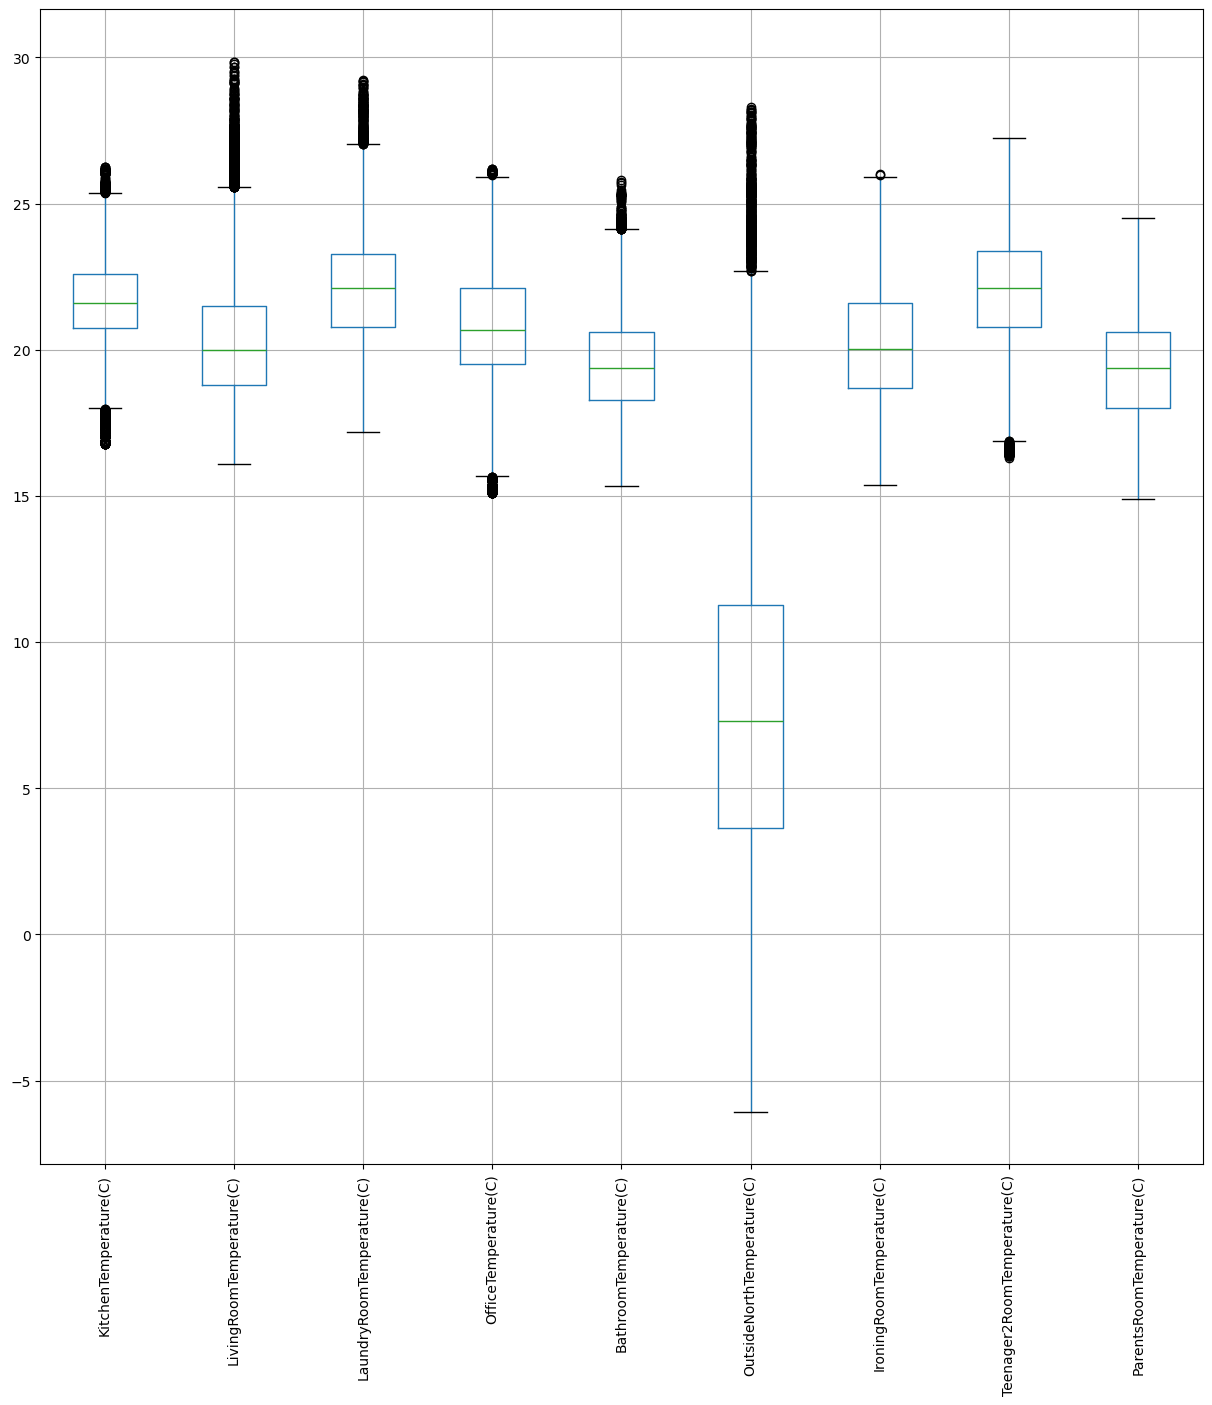

In [26]:
## Plot boxplot for different features
df.drop(['EnergyUse(Wh)'], axis=1).boxplot(rot=90, figsize=(15, 15)) ## rot: rotation of label
plt.show()

### 2.3.2 Understanding relationship between variables

In [27]:
## Understanding relationship between variables
## Check datatypes for each column
col_numeric = df.select_dtypes(include=['float', 'int']).columns ## Select all categorical columns

## Display correlation matrix
df_corr = df[col_numeric].corr()
df_corr

,EnergyUse(Wh),KitchenTemperature(C),LivingRoomTemperature(C),LaundryRoomTemperature(C),OfficeTemperature(C),BathroomTemperature(C),OutsideNorthTemperature(C),IroningRoomTemperature(C),Teenager2RoomTemperature(C),ParentsRoomTemperature(C)
EnergyUse(Wh),1.000000,0.055447,0.120073,0.085060,0.040281,0.019760,0.117638,0.025801,0.039572,0.010010
KitchenTemperature(C),0.055447,1.000000,0.836834,0.892402,0.877001,0.885247,0.654769,0.838705,0.825413,0.844777
LivingRoomTemperature(C),0.120073,0.836834,1.000000,0.735245,0.762066,0.720550,0.801186,0.663660,0.578191,0.675535
LaundryRoomTemperature(C),0.085060,0.892402,0.735245,1.000000,0.852778,0.888169,0.686882,0.847374,0.795283,0.901324
OfficeTemperature(C),0.040281,0.877001,0.762066,0.852778,1.000000,0.871813,0.652350,0.877763,0.796256,0.889439
BathroomTemperature(C),0.019760,0.885247,0.720550,0.888169,0.871813,1.000000,0.629161,0.870624,0.824981,0.911055
OutsideNorthTemperature(C),0.117638,0.654769,0.801186,0.686882,0.652350,0.629161,1.000000,0.619085,0.482836,0.667177
IroningRoomTemperature(C),0.025801,0.838705,0.663660,0.847374,0.877763,0.870624,0.619085,1.000000,0.882123,0.944776
Teenager2RoomTemperature(C),0.039572,0.825413,0.578191,0.795283,0.796256,0.824981,0.482836,0.882123,1.000000,0.869338
ParentsRoomTemperature(C),0.010010,0.844777,0.675535,0.901324,0.889439,0.911055,0.667177,0.944776,0.869338,1.000000


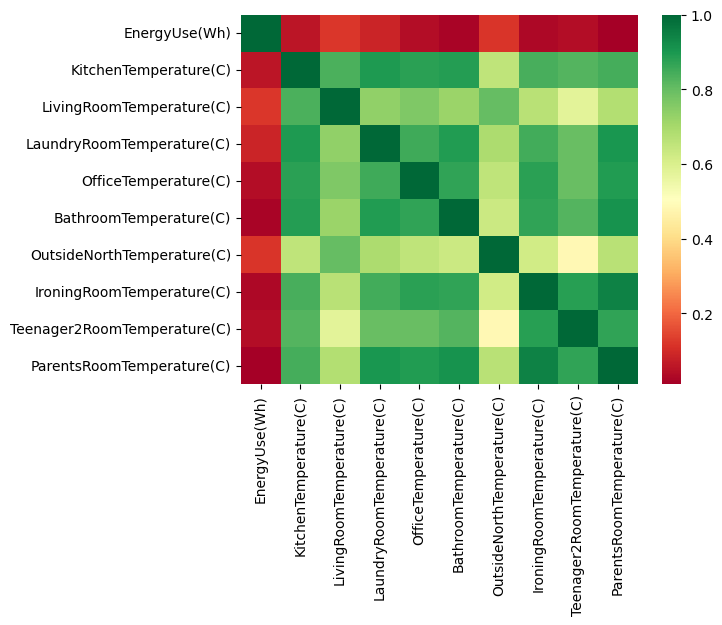

In [28]:
## Plot heatmap
sns.heatmap(df_corr, cmap='RdYlGn')
plt.show()

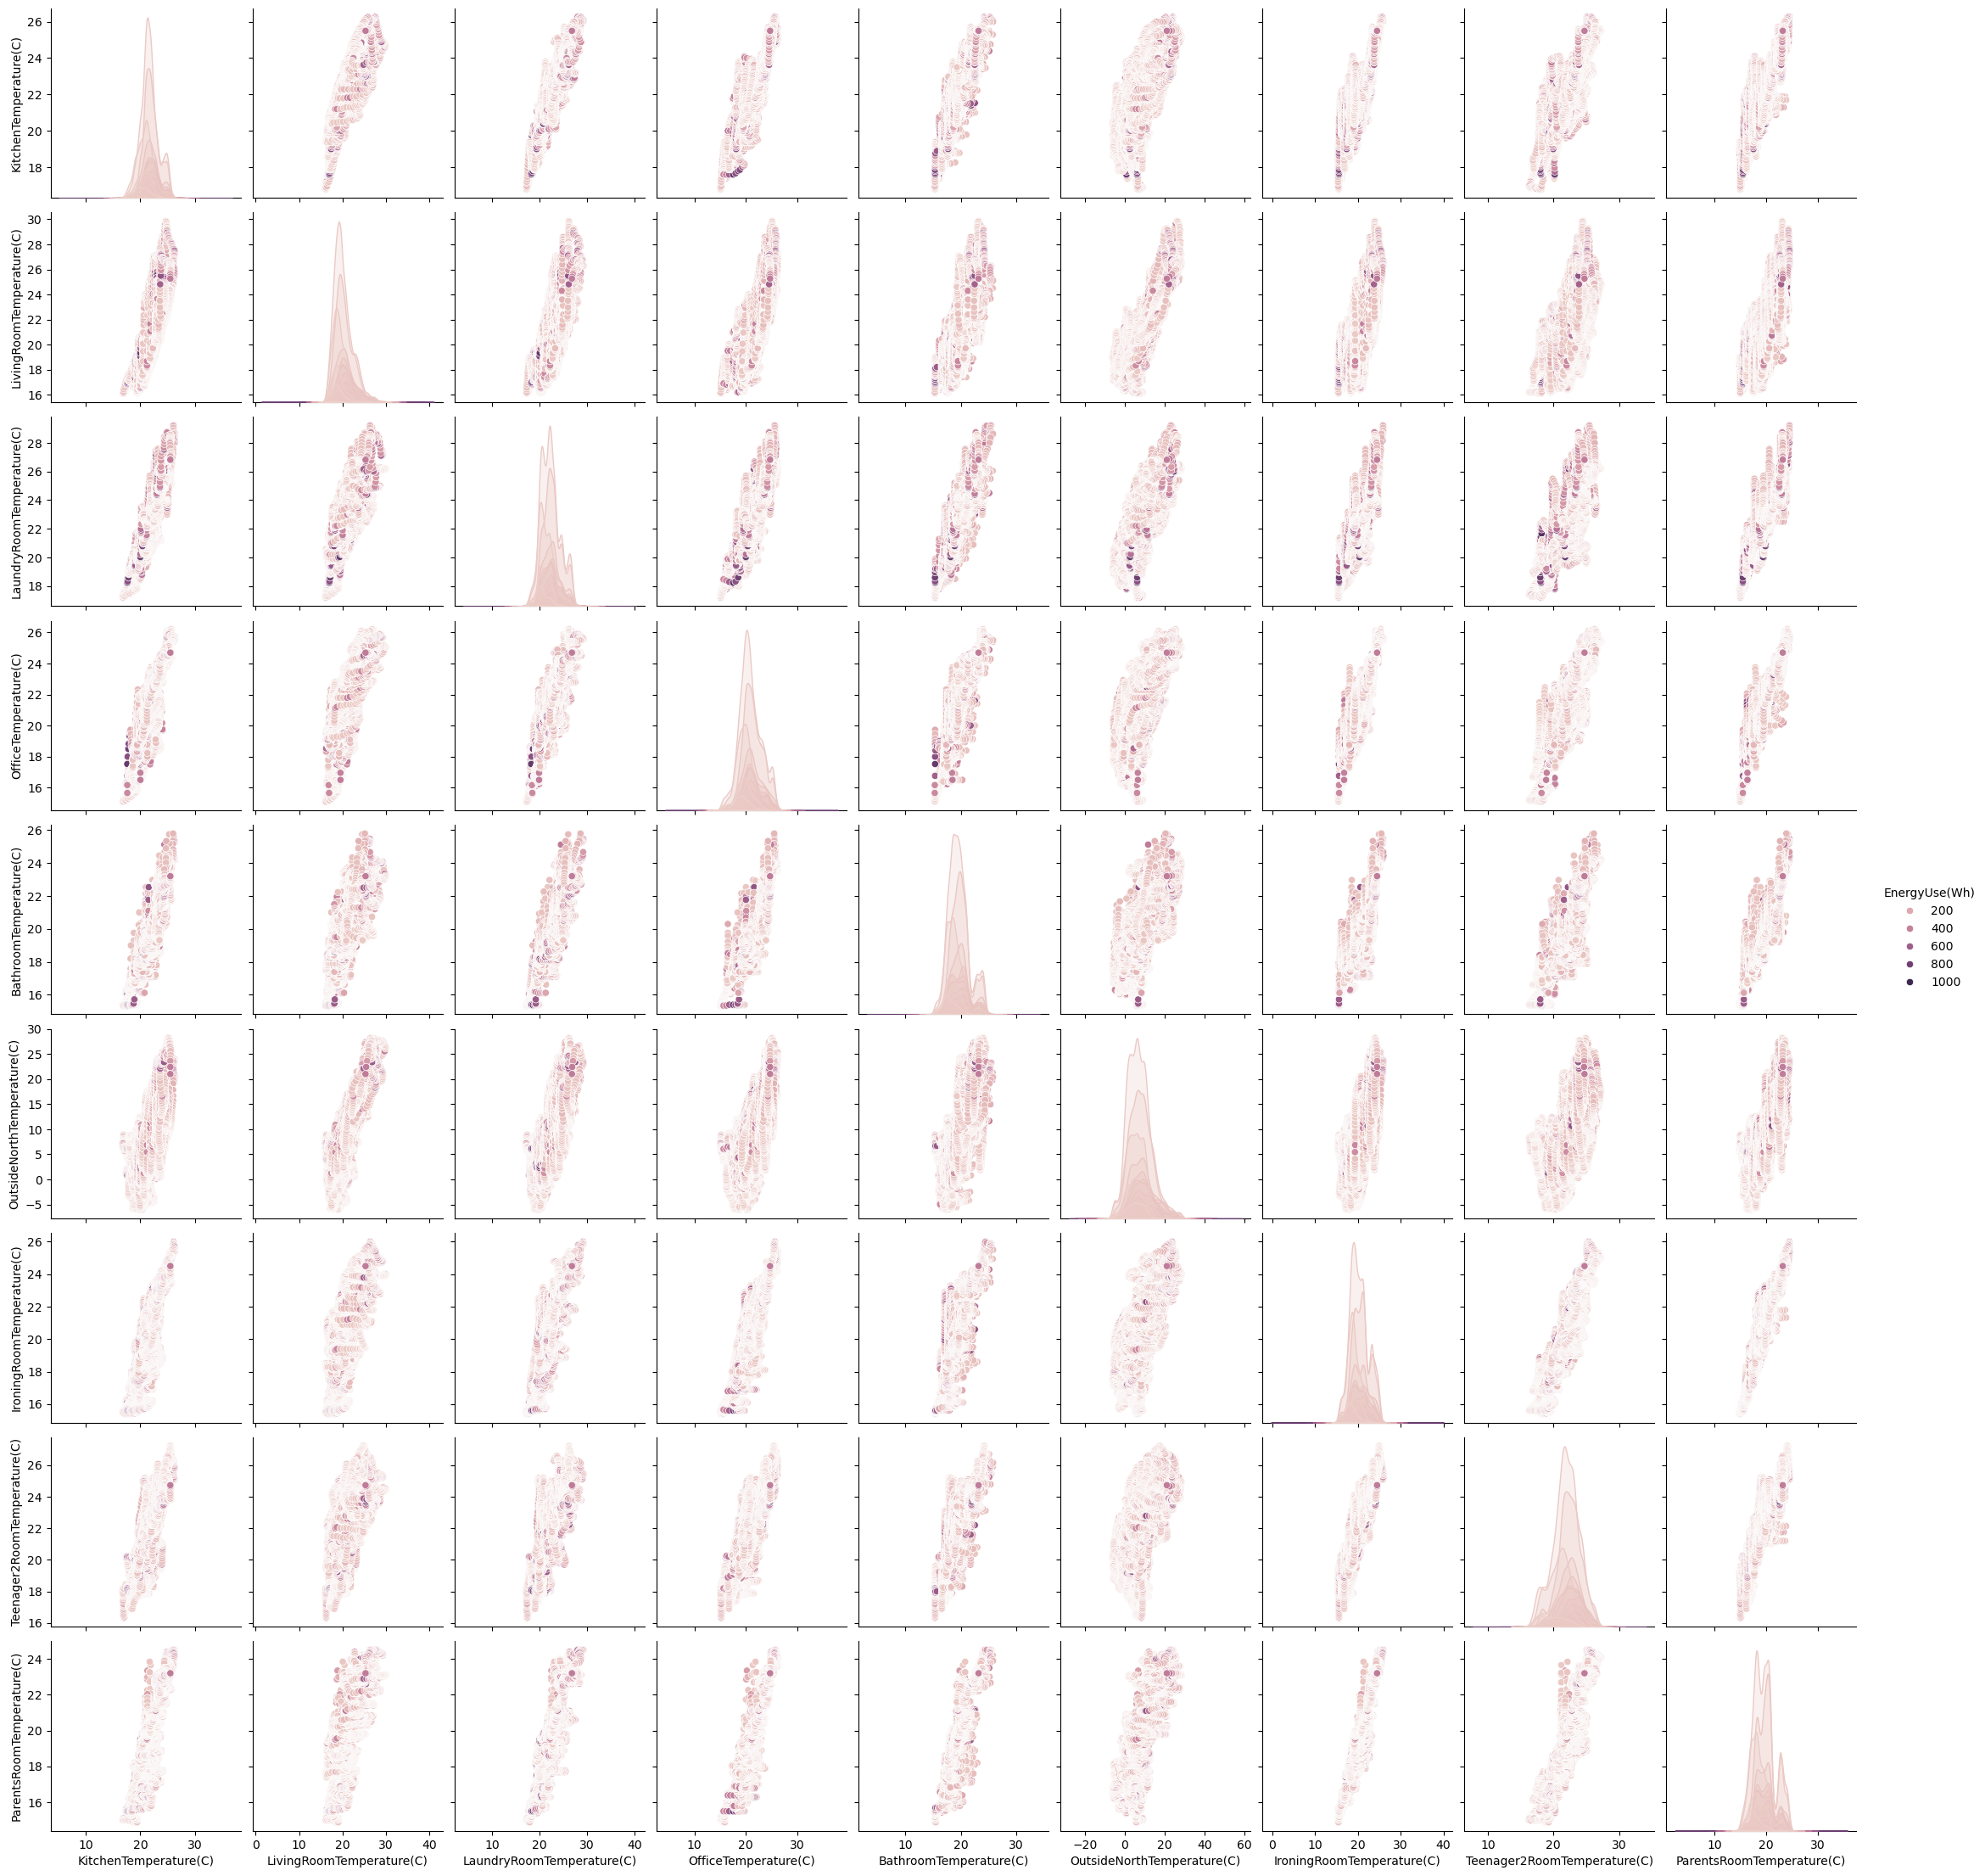

In [29]:
## Plot pairplot
sns.pairplot(df, hue=col_y)
plt.show()

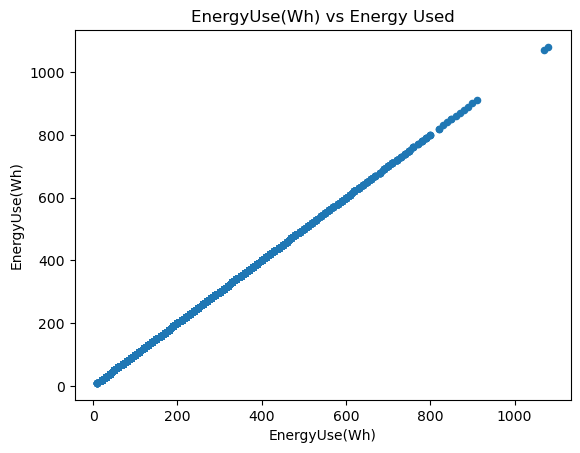

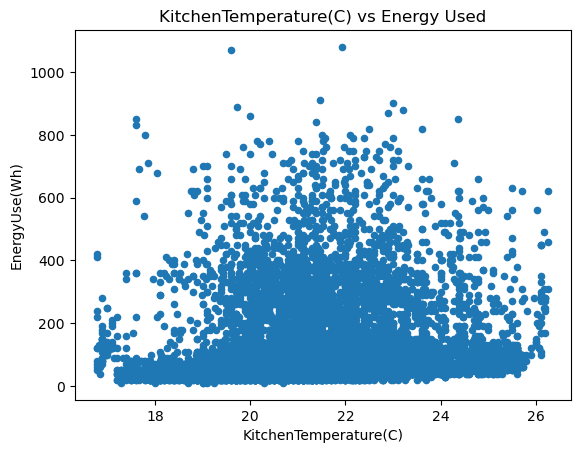

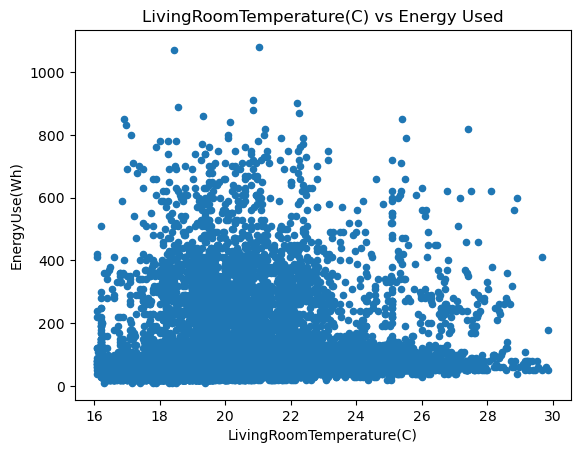

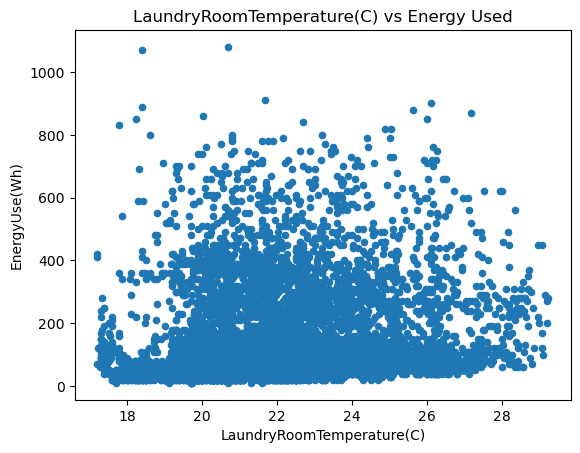

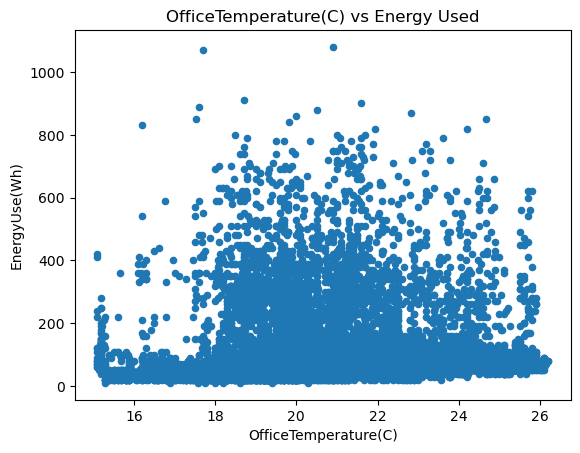

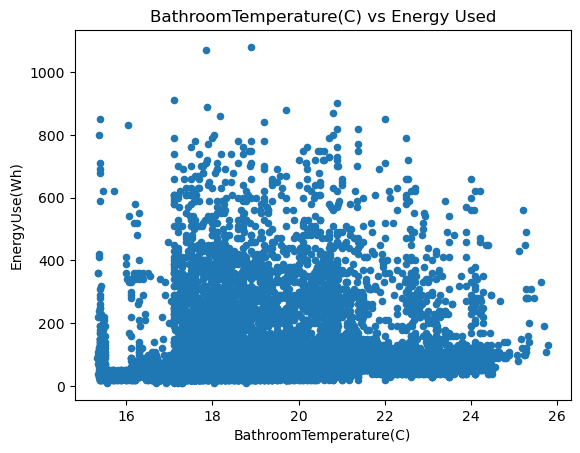

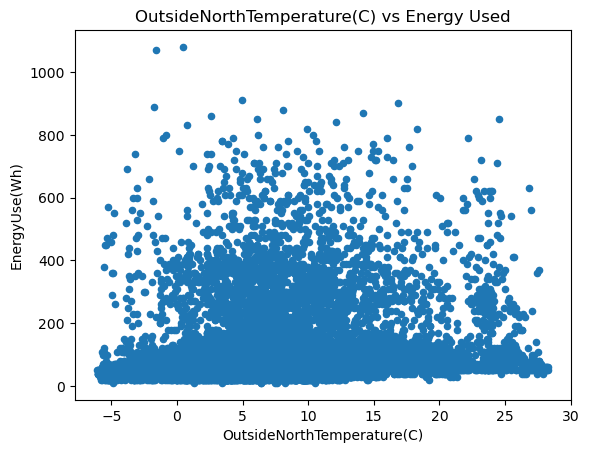

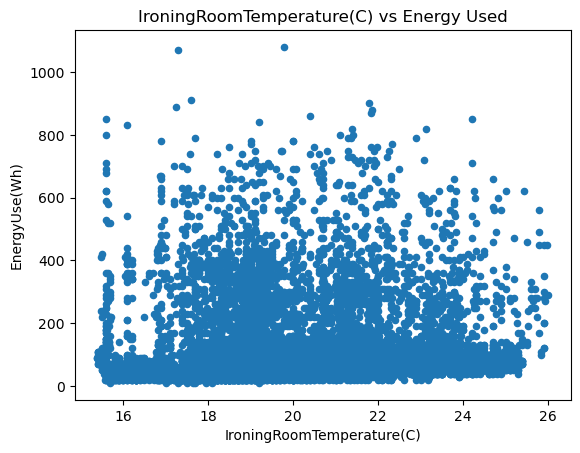

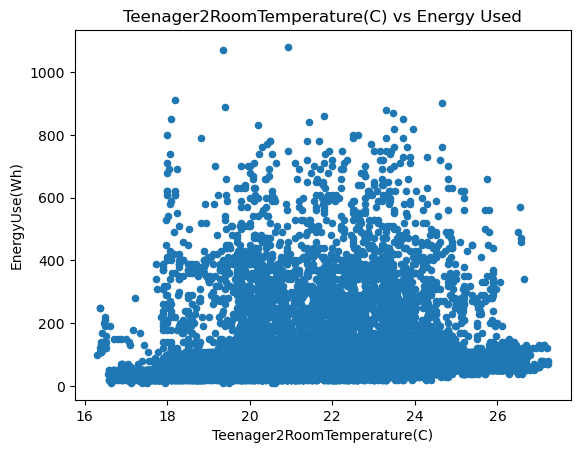

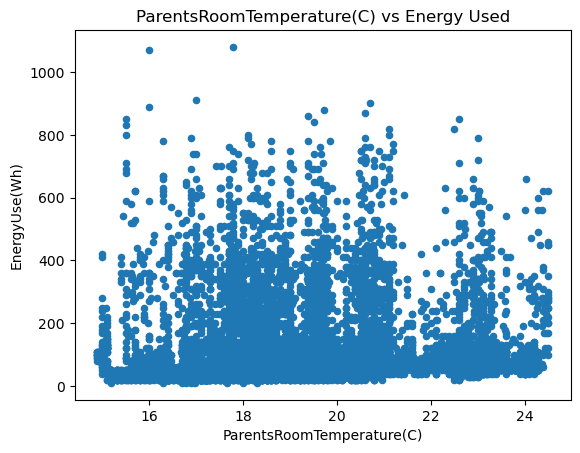

In [30]:
for col_x in df.columns:
    df.plot(x=col_x,
            y=col_y,
            kind='scatter')
    plt.title(f"{col_x} vs Energy Used")
    plt.suptitle('')  # Remove default title by Pandas
    plt.xlabel(col_x)
    plt.ylabel(col_y)
    plt.show()

# 3. Data Preparation

## 3.1 Data Cleaning

In [31]:
## Clean data

## 3.2 Train-Test Split

In [32]:
## Split data into train set and test set


# 4. Modelling

### 4.2 Train Model

In [33]:
## Initialise and train model


# 5. Model Evaluation

In [34]:
## Evaluate model


In [35]:
## New data

## Predict


## Iterative model development


In [36]:
## Further feature engineering / feature selection